# Hari 8-9 — Investigasi Outlier & Penerapan Koreksi

**Recap keputusan Hari 7:** minggu-minggu outlier yang terdeteksi akan **diselidiki manual satu-satu** (cek berita/konteks pada tanggal tersebut), bukan langsung di-smooth otomatis atau dibiarkan begitu saja.

Dua bagian: **Hari 8** — bangun ulang pipeline sampai deteksi outlier, lalu investigasi tiap tanggal pakai tabel referensi gelombang COVID-19 Indonesia. **Hari 9** — terapkan keputusan hasil investigasi ke dataset.

---
# BAGIAN A — Hari 8: Investigasi Outlier

In [28]:
# Cell ini membangun ulang seluruh pipeline dari Hari 3-6 (boilerplate, sudah pernah kamu
# tulis sendiri di notebook sebelumnya) supaya notebook Hari 8-9 ini bisa jalan sendiri
# tanpa harus buka-tutup notebook lama.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

vaksin = pd.read_csv("vaksinasi.csv")
kasus = pd.read_csv("harian.csv")

vaksin["Date"] = pd.to_datetime(vaksin["key_as_string"], utc=True)
kasus["Date"] = pd.to_datetime(kasus["key_as_string"], utc=True)
vaksin = vaksin.sort_values("Date").set_index("Date")
kasus = kasus.sort_values("Date").set_index("Date")

kasus_mingguan = kasus["jumlah_positif"].resample("W").sum().rename("kasus_baru_mingguan")
vaksin_mingguan = vaksin["jumlah_jumlah_vaksinasi_1_kum"].resample("W").last().rename("vaksin_dosis1_kumulatif")
gabungan = pd.concat([kasus_mingguan, vaksin_mingguan], axis=1)

gabungan["vaksin_dosis1_kumulatif"] = gabungan["vaksin_dosis1_kumulatif"].fillna(0)
POPULASI_INDONESIA = 270_203_917
gabungan["vaksin_persen"] = (gabungan["vaksin_dosis1_kumulatif"] / POPULASI_INDONESIA) * 100
gabungan = gabungan.drop(columns=["vaksin_dosis1_kumulatif"])

series = gabungan["kasus_baru_mingguan"].interpolate()
decomposition = seasonal_decompose(series, model="additive", period=52)
residual = decomposition.resid.dropna()

Q1 = residual.quantile(0.25)
Q3 = residual.quantile(0.75)
IQR = Q3 - Q1
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR
outlier_weeks = residual[(residual < batas_bawah) | (residual > batas_atas)]

print(f"Ditemukan {len(outlier_weeks)} minggu terindikasi outlier:\n")
for tanggal in outlier_weeks.index:
    nilai = gabungan.loc[tanggal, "kasus_baru_mingguan"]
    print(f"  {tanggal.date()}  →  {nilai:,.0f} kasus baru minggu itu")

Ditemukan 4 minggu terindikasi outlier:

  2021-02-21  →  61,185 kasus baru minggu itu
  2021-02-28  →  55,981 kasus baru minggu itu
  2022-02-20  →  389,727 kasus baru minggu itu
  2022-02-27  →  341,889 kasus baru minggu itu


## Referensi: Timeline Gelombang COVID-19 Indonesia (2020-2022)

Cocokkan tiap tanggal outlier di atas dengan tabel ini sebagai titik awal investigasi:

| Periode | Gelombang | Puncak | Catatan |
|---|---|---|---|
| Mar–Des 2020 | Gelombang 1 (awal pandemi) | ±Desember 2020, ~6.000–8.000 kasus/hari | Sistem pelaporan belum matang di awal pandemi → rawan revisi angka & keterlambatan |
| Jun–Okt 2021 | Gelombang 2 (Delta) | 15 Juli 2021, 56.757 kasus/hari (puncak harian tertinggi saat itu) | Lonjakan sangat tajam dalam waktu singkat; PPKM Darurat mulai awal Juli 2021 |
| Jan–Mar 2022 | Gelombang 3 (Omicron) | ±16-17 Februari 2022, ~63.000–65.000 kasus/hari | Naik cepat, turun cepat juga setelah puncak (berbeda pola dari Delta) |
| Akhir Des–awal Jan (tiap tahun) | — | — | Pola berulang: lonjakan pelaporan 2-3 minggu **setelah** libur Natal & Tahun Baru — ini efek keterlambatan lapor, bukan lonjakan penularan riil di tanggal tersebut |

**Aturan praktis:** kalau tanggal outlier kamu jatuh dekat salah satu periode puncak gelombang di atas, kemungkinan besar itu **sinyal asli** → kandidat keputusan "pertahankan". Kalau tanggalnya di luar periode-periode ini (misalnya pertengahan bulan tenang, tidak dekat gelombang manapun), curigai **artefak pelaporan** → kandidat keputusan "koreksi" atau "smoothing lokal". Ini cuma titik awal — kamu tetap boleh cari berita spesifik di tanggal tersebut untuk mengonfirmasi.

In [29]:
# Cell ini membuat tabel kosong untuk kamu isi hasil investigasi.
# Kolom "kemungkinan_penyebab" dan "keputusan" sengaja dikosongkan (placeholder "???").

investigasi = pd.DataFrame({
    "kasus_baru_mingguan": gabungan.loc[outlier_weeks.index, "kasus_baru_mingguan"],
    "kemungkinan_penyebab": "???",
    "keputusan": "smoothing_lokal",  # isi salah satu: "pertahankan" / "koreksi" / "smoothing_lokal"
})
investigasi

,kasus_baru_mingguan,kemungkinan_penyebab,keputusan
Date,,,
2021-02-21 00:00:00+00:00,61185,???,smoothing_lokal
2021-02-28 00:00:00+00:00,55981,???,smoothing_lokal
2022-02-20 00:00:00+00:00,389727,???,smoothing_lokal
2022-02-27 00:00:00+00:00,341889,???,smoothing_lokal


## Isi Hasil Investigasi Kamu

Untuk tiap baris di tabel `investigasi` di atas, ganti nilai `"???"` dengan hasil investigasimu. Cara mengubah satu sel di pandas: `investigasi.loc[tanggal, "nama_kolom"] = "nilai baru"`.

Contoh (ganti `tanggal` dengan salah satu tanggal asli dari tabelmu, dan sesuaikan isinya):
```python
investigasi.loc["2021-07-18", "kemungkinan_penyebab"] = "Dekat puncak gelombang Delta (15 Juli 2021) — sinyal asli"
investigasi.loc["2021-07-18", "keputusan"] = "pertahankan"
```

Ulangi baris di bawah untuk **setiap tanggal** di tabel `investigasi` kamu (jumlah baris kode = jumlah tanggal outlier yang terdeteksi):

In [ ]:
# LATIHAN — isi investigasi.loc[...] untuk SETIAP tanggal yang muncul di tabel `investigasi` di atas.
# Untuk kolom "keputusan", gunakan salah satu dari tiga nilai berikut (harus persis
# sama ejaannya, karena akan dipakai logika program di Hari 9):
#   "pertahankan"     -> data dianggap valid, tidak diubah
#   "koreksi"         -> kamu tahu nilai yang lebih tepat, akan diganti manual
#   "smoothing_lokal" -> nilai akan digantikan rata-rata minggu di sekitarnya
# Setelah selesai isi semua baris, cetak ulang `investigasi` untuk mengecek hasilnya.
# Tulis kode kamu di bawah ini:
investigasi.loc["2021-02-21", "kemungkinan_penyebab"] = "Keterlambatan laporan - artefak pelaporan"
investigasi.loc["2021-02-21", "keputusan"] = "smoothing_lokal"

investigasi.loc["2021-02-28", "kemungkinan_penyebab"] = "Keterlambatan laporan - artefak pelaporan"
investigasi.loc["2021-02-28", "keputusan"] = "smoothing_lokal"

investigasi.loc["2022-02-20", "kemungkinan_penyebab"] = "Dekat puncak gelombang 3 (Omicron) - sinyal asli"
investigasi.loc["2022-02-20 ", "keputusan"] = "pertahankan"

investigasi.loc["2022-02-27", "kemungkinan_penyebab"] = "Dekat puncak gelombang 3 (Omicron) - sinyal asli"
investigasi.loc["2022-02-27", "keputusan"] = "pertahankan"

investigasi

,kasus_baru_mingguan,kemungkinan_penyebab,keputusan
Date,,,
2021-02-21 00:00:00+00:00,61185,Keterlambatan laporan - artefak pelaporan,smoothing_lokal
2021-02-28 00:00:00+00:00,55981,Keterlambatan laporan - artefak pelaporan,smoothing_lokal
2022-02-20 00:00:00+00:00,389727,Dekat puncak gelombang 3 (Omicron) - sinyal asli,pertahankan
2022-02-27 00:00:00+00:00,341889,Dekat puncak gelombang 3 (Omicron) - sinyal asli,pertahankan


---
# BAGIAN B — Hari 9: Menerapkan Koreksi ke Dataset

Sekarang kita terapkan keputusan dari tabel `investigasi` ke dataframe `gabungan` secara terprogram — bukan diedit manual satu-satu, supaya prosesnya bisa diulang kalau datanya berubah (misal kamu update dataset di kemudian hari).

In [39]:
# LATIHAN — tulis kodenya sendiri sesuai panduan komentar di bawah:
# Kita akan looping tiap baris di `investigasi`, lalu terapkan aksi berbeda tergantung nilai kolom "keputusan":
# 1. Buat salinan dataframe dulu supaya data asli tidak tertimpa:
#    gabungan_bersih = gabungan.copy()
# 2. Loop tiap baris investigasi dengan: for tanggal, baris in investigasi.iterrows():
# 3. Di dalam loop, cek nilai baris["keputusan"]:
#    - Kalau == "pertahankan": tidak perlu melakukan apa-apa (pass)
#    - Kalau == "smoothing_lokal": ganti gabungan_bersih.loc[tanggal, "kasus_baru_mingguan"]
#      dengan rata-rata dari 2 minggu sebelum dan 2 minggu sesudah tanggal tsb.
#      Hint: pakai gabungan_bersih["kasus_baru_mingguan"].rolling(5, center=True).mean()
#      lalu ambil nilai pada tanggal tersebut dari hasil rolling itu.
#    - Kalau == "koreksi": untuk latihan ini, cukup print pesan pengingat bahwa baris ini
#      butuh input manual (karena nilai koreksi yang tepat tergantung hasil investigasimu
#      sendiri, tidak bisa dihitung otomatis dari rumus).
# 4. Setelah loop selesai, cetak gabungan_bersih.loc[outlier_weeks.index] untuk
#    membandingkan nilai sebelum vs sesudah koreksi.
# Tulis kode kamu di bawah ini:
gabungan_bersih = gabungan.copy()
gabungan_bersih["kasus_baru_mingguan"] = gabungan_bersih["kasus_baru_mingguan"].astype(float)
masked = gabungan["kasus_baru_mingguan"].copy()
masked.loc[outlier_weeks.index] = np.nan  # buang semua titik outlier dulu
rolling_kasus = masked.rolling(5, center=True, min_periods=1).mean()
#rolling_kasus = (gabungan["kasus_baru_mingguan"].rolling(5, center=True).mean())
for tanggal, baris in investigasi.iterrows():
    keputusan = baris["keputusan"]
    if keputusan == "pertahankan":
        pass
    elif keputusan == "smoothing_lokal":
        gabungan_bersih.loc[tanggal, "kasus_baru_mingguan"] = rolling_kasus.loc[tanggal]
    elif keputusan == "koreksi":
        print(f"Baris {tanggal} membutuhkan koreksi manual.")
    else:
        print(f"Keputusan tidak dikenal: {keputusan}")
print(gabungan_bersih.loc[outlier_weeks.index])

                           kasus_baru_mingguan  vaksin_persen
Date                                                         
2021-02-21 00:00:00+00:00         61394.000000       0.000000
2021-02-28 00:00:00+00:00         48150.666667       0.000000
2022-02-20 00:00:00+00:00        389727.000000      70.186591
2022-02-27 00:00:00+00:00        341889.000000      70.566171


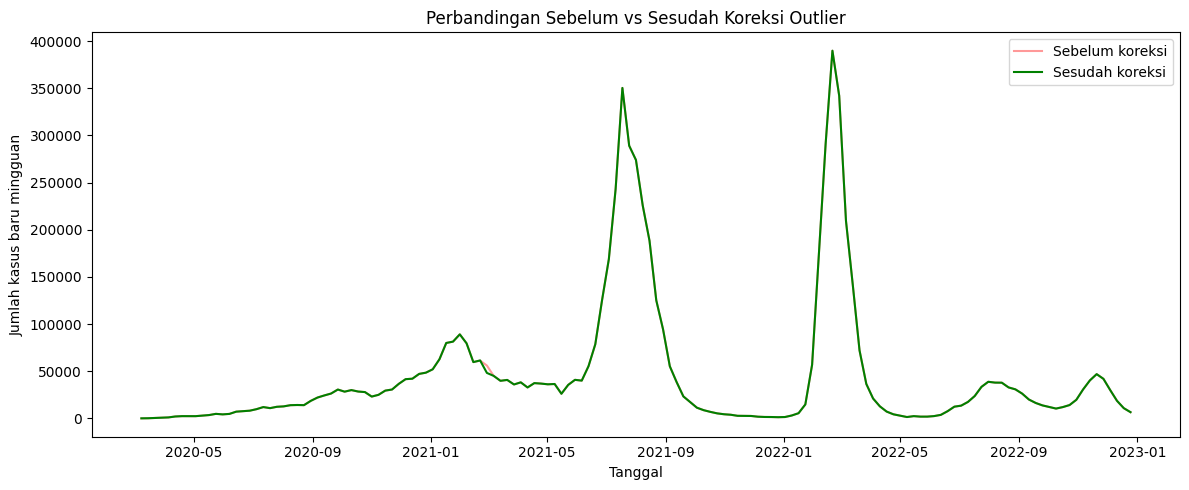

In [40]:
# LATIHAN — tulis kodenya sendiri sesuai panduan komentar di bawah:
# Bandingkan visual data sebelum dan sesudah koreksi dalam satu grafik:
# 1. Buat figure (plt.figure(figsize=(12, 5)))
# 2. Plot gabungan["kasus_baru_mingguan"] (versi ASLI) dengan alpha=0.4, label "Sebelum koreksi"
# 3. Plot gabungan_bersih["kasus_baru_mingguan"] (versi SUDAH dikoreksi) dengan warna berbeda, label "Sesudah koreksi"
# 4. Tambahkan legend, title "Perbandingan Sebelum vs Sesudah Koreksi Outlier", tight_layout, show
# Tulis kode kamu di bawah ini:
plt.figure(figsize=(12, 5))
plt.plot(
    gabungan["kasus_baru_mingguan"],
    color="red",
    alpha=0.4,
    label="Sebelum koreksi"
)
plt.plot(
    gabungan_bersih["kasus_baru_mingguan"],
    color="green",
    label="Sesudah koreksi"
)
plt.title("Perbandingan Sebelum vs Sesudah Koreksi Outlier")
plt.xlabel("Tanggal")
plt.ylabel("Jumlah kasus baru mingguan")
plt.legend()
plt.tight_layout()
plt.show()

## Simpan Dataset Bersih untuk Minggu Berikutnya

In [41]:
# Cell ini sudah lengkap — menyimpan hasil akhir Data Preparation tahap awal
# supaya bisa langsung dipakai di Hari 10-14 tanpa mengulang semua proses dari nol.

gabungan_bersih.to_csv("dataset_bersih_minggu2.csv")
print("Tersimpan sebagai dataset_bersih_minggu2.csv")
print(f"Shape akhir: {gabungan_bersih.shape}")
gabungan_bersih.tail()

Tersimpan sebagai dataset_bersih_minggu2.csv
Shape akhir: (147, 2)


,kasus_baru_mingguan,vaksin_persen
Date,,
2022-11-27 00:00:00+00:00,41877.0,76.020068
2022-12-04 00:00:00+00:00,29959.0,75.398628
2022-12-11 00:00:00+00:00,18587.0,75.434557
2022-12-18 00:00:00+00:00,10807.0,75.464296
2022-12-25 00:00:00+00:00,6527.0,75.489253


## Refleksi Hari 8-9

Isi bagian ini untuk melengkapi catatan Data Preparation kamu:

> 1. Dari semua outlier yang terdeteksi, berapa yang ternyata sinyal asli (pertahankan) vs berapa yang dikoreksi/di-smooth? → 2 sinyal asli vs 2 di-smoothing
> 2. Apakah ada pola dari investigasimu (misal: sebagian besar outlier ternyata dekat gelombang Delta/Omicron, atau malah dekat libur Nataru)? → sebagian outlier ternyata dekat gelombang Delta/Omicron

---
### Selanjutnya: Hari 10-11 — Feature Engineering

Dengan `dataset_bersih_minggu2.csv` sebagai fondasi, Hari 10-11 fokus membangun fitur yang benar-benar dipakai model forecasting nanti:
- **Fitur lag**: kasus_baru_mingguan pada minggu t-1, t-2, t-3 (nilai historis sebagai prediktor)
- **Rolling average**: rata-rata 4 minggu terakhir sebagai fitur tambahan (menangkap tren jangka pendek)
- **Fitur vaksinasi**: `vaksin_persen` yang sudah kamu siapkan dari Hari 5 tinggal dipakai langsung sebagai fitur eksternal

Ingat: untuk data time-series, fitur lag artinya kamu "menggeser" data ke belakang — pastikan tidak ada *data leakage* (jangan sampai fitur mengandung informasi dari masa depan relatif terhadap target yang diprediksi).